In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Nice defaults
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

df = pd.read_csv("../data/crimes_raw.csv")
print(f"Shape: {df.shape}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (18263, 10)


,category,location_type,persistent_id,id,location_subtype,month,latitude,longitude,street_name,outcome_category
0,anti-social-behaviour,Force,NaN,116047497,NaN,2024-01,53.792888,-1.539660,On or near Waterloo Street,Unknown
1,anti-social-behaviour,Force,NaN,116047604,NaN,2024-01,53.804566,-1.537968,On or near Lovell Park Hill,Unknown
2,anti-social-behaviour,Force,NaN,116047501,NaN,2024-01,53.800938,-1.543535,On or near Nightclub,Unknown
3,anti-social-behaviour,Force,NaN,116047500,NaN,2024-01,53.796033,-1.541964,On or near Duncan Street,Unknown
4,anti-social-behaviour,Force,NaN,116046908,NaN,2024-01,53.795991,-1.540218,On or near Shopping Area,Unknown


In [2]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Unique values per column ===")
print(df.nunique())

=== Data Types ===
category                str
location_type           str
persistent_id           str
id                    int64
location_subtype        str
month                   str
latitude            float64
longitude           float64
street_name             str
outcome_category        str
dtype: object

=== Missing Values ===
category                0
location_type           0
persistent_id        1092
id                      0
location_subtype    18126
month                   0
latitude                0
longitude               0
street_name             0
outcome_category        0
dtype: int64

=== Unique values per column ===
category               14
location_type           2
persistent_id       17170
id                  18263
location_subtype        1
month                  12
latitude              538
longitude             544
street_name           456
outcome_category       13
dtype: int64


In [3]:
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month")
print("Month range:", df["month"].min(), "→", df["month"].max())        

Month range: 2024-01-01 00:00:00 → 2024-12-01 00:00:00


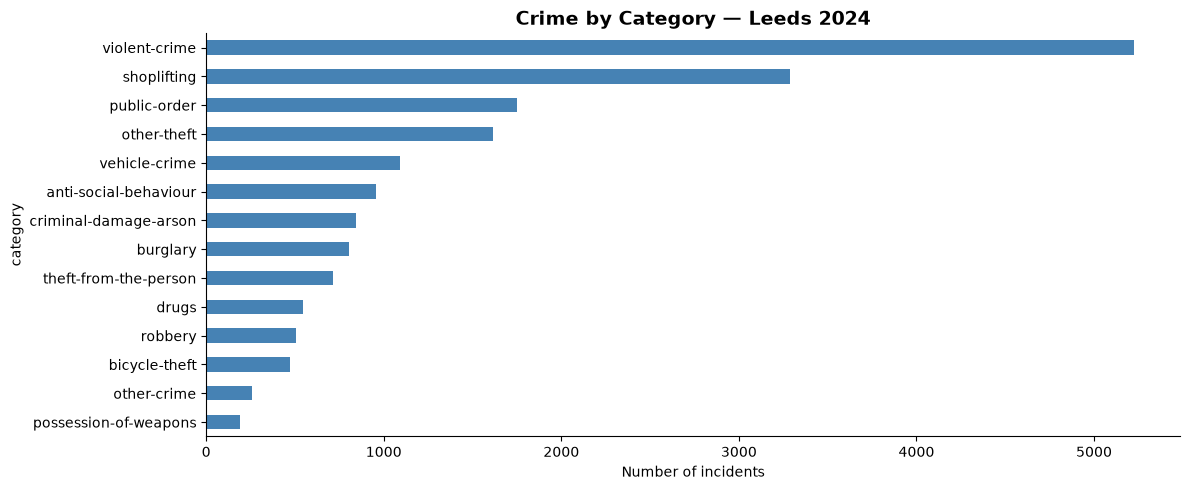

category
violent-crime            5223
shoplifting              3287
public-order             1749
other-theft              1617
vehicle-crime            1092
anti-social-behaviour     955
criminal-damage-arson     846
burglary                  807
theft-from-the-person     715
drugs                     547
robbery                   507
bicycle-theft             470
other-crime               260
possession-of-weapons     188
Name: count, dtype: int64


In [4]:
category_counts = df["category"].value_counts()

fig, ax = plt.subplots()
category_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Crime by Category — Leeds 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of incidents")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/chart_categories.png", dpi=150)
plt.show()
print(category_counts)

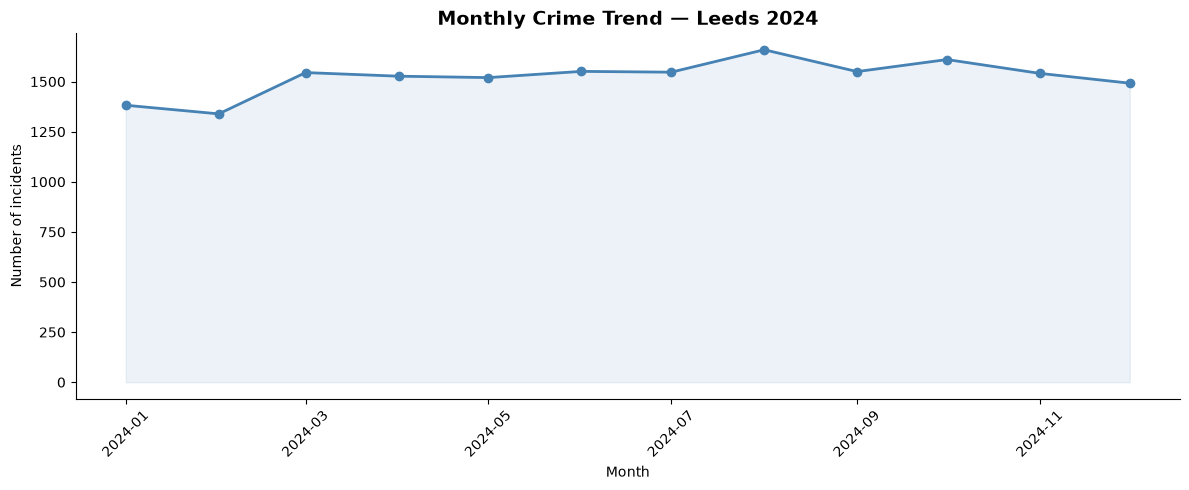

In [5]:
monthly = df.groupby("month").size().reset_index(name="count")

fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["count"], marker="o", linewidth=2, color="steelblue")
ax.fill_between(monthly["month"], monthly["count"], alpha=0.1, color="steelblue")
ax.set_title("Monthly Crime Trend — Leeds 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/chart_monthly_trend.png", dpi=150)
plt.show()

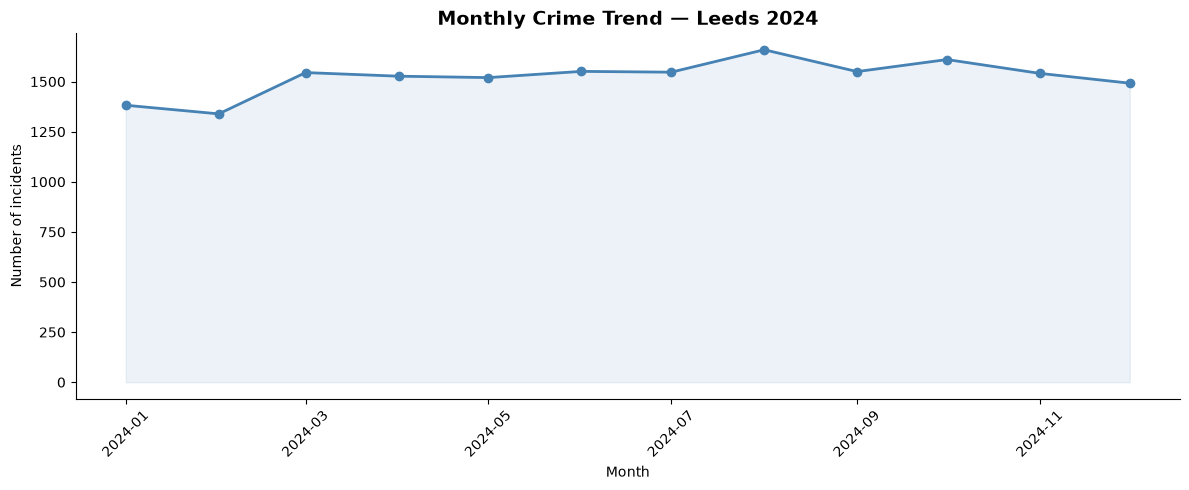

In [6]:
monthly = df.groupby("month").size().reset_index(name="count")

fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["count"], marker="o", linewidth=2, color="steelblue")
ax.fill_between(monthly["month"], monthly["count"], alpha=0.1, color="steelblue")
ax.set_title("Monthly Crime Trend — Leeds 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/chart_monthly_trend.png", dpi=150)
plt.show()

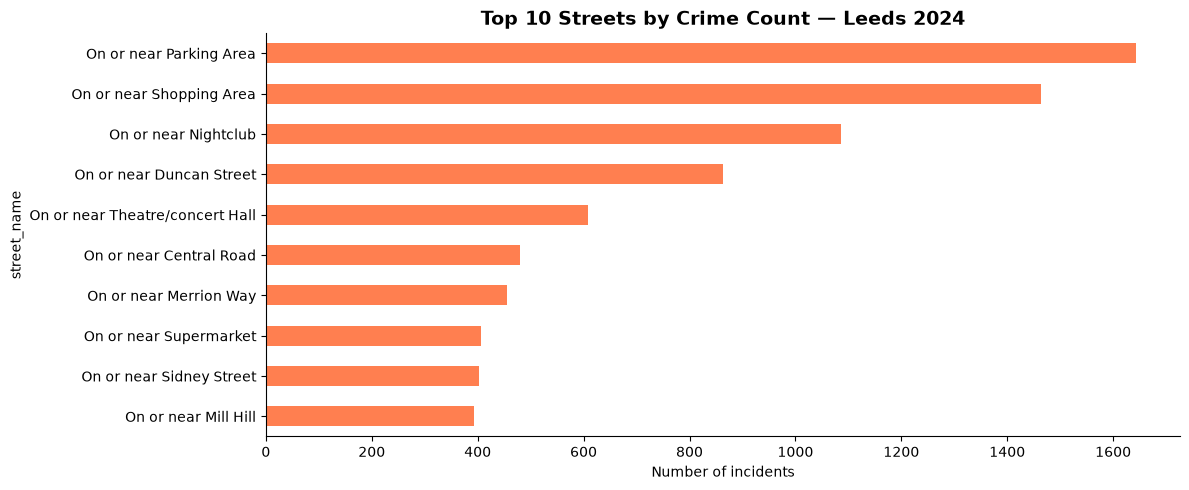

In [7]:
top_streets = df["street_name"].value_counts().head(10)

fig, ax = plt.subplots()
top_streets.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 10 Streets by Crime Count — Leeds 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of incidents")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/chart_top_streets.png", dpi=150)
plt.show()

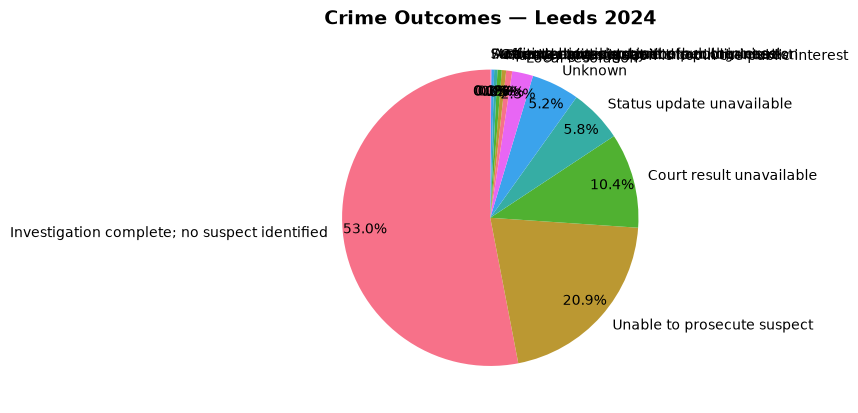

In [8]:
outcome_counts = df["outcome_category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
outcome_counts.plot(
    kind="pie", ax=ax,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85,
)
ax.set_title("Crime Outcomes — Leeds 2024", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../data/chart_outcomes.png", dpi=150)
plt.show()

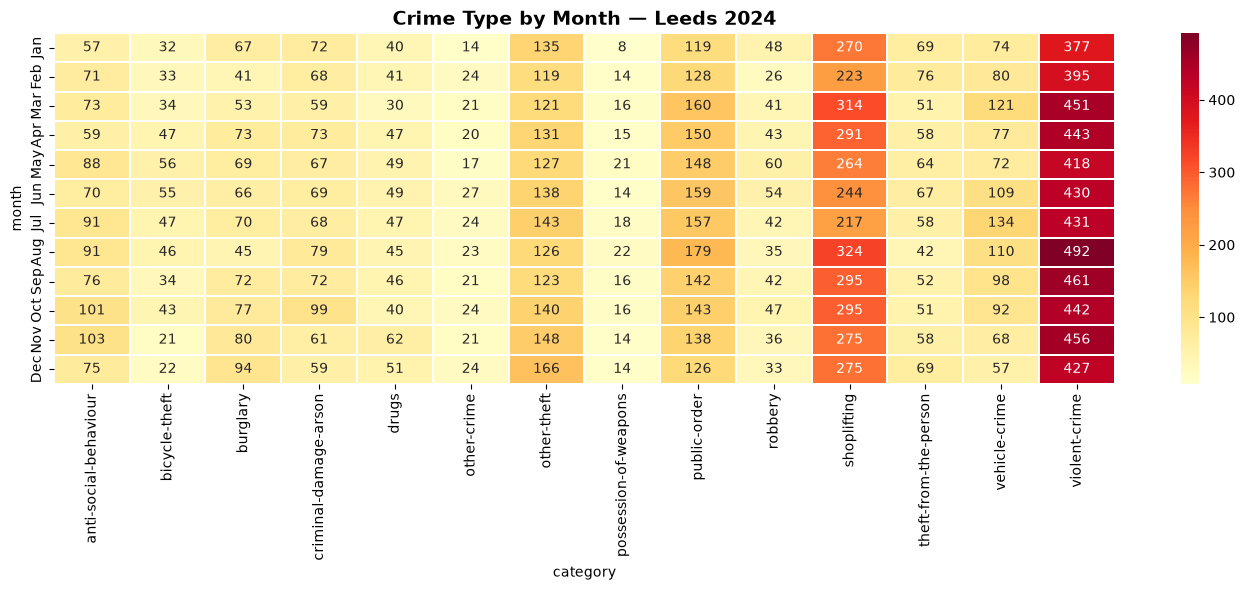

In [9]:
pivot = df.groupby(
    [df["month"].dt.strftime("%b"), "category"]
).size().unstack(fill_value=0)

# reorder months chronologically
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
pivot = pivot.reindex([m for m in month_order if m in pivot.index])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3, annot=True, fmt="d")
ax.set_title("Crime Type by Month — Leeds 2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/chart_heatmap.png", dpi=150)
plt.show()

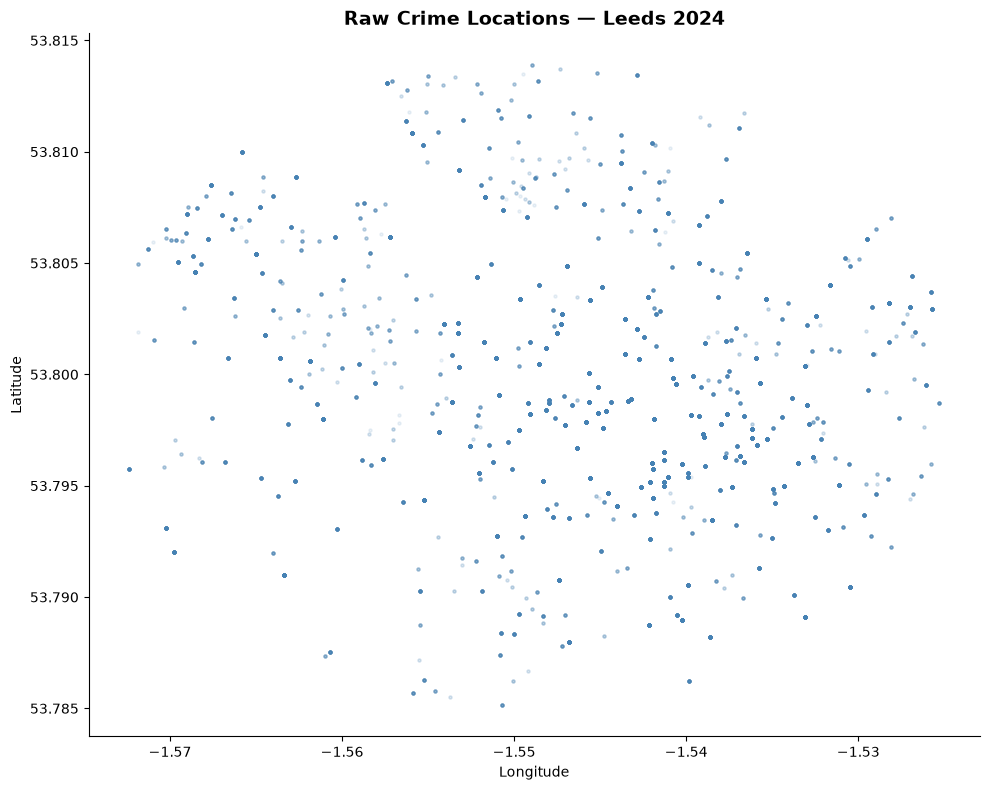

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    df["longitude"], df["latitude"],
    alpha=0.1, s=5, color="steelblue"
)
ax.set_title("Raw Crime Locations — Leeds 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("../data/chart_raw_locations.png", dpi=150)
plt.show()